In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
df = pd.read_pickle("/Users/a./Wafer_project/wafer-defects/data/LSWMD.pkl")

In [18]:
df.shape


(811457, 6)

In [19]:
df.head()

,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


In [20]:
first_map = df.loc[0,"waferMap"]
print(type(first_map))
print(first_map.shape)
print(np.unique(first_map))


<class 'numpy.ndarray'>
(45, 48)
[0 1 2]


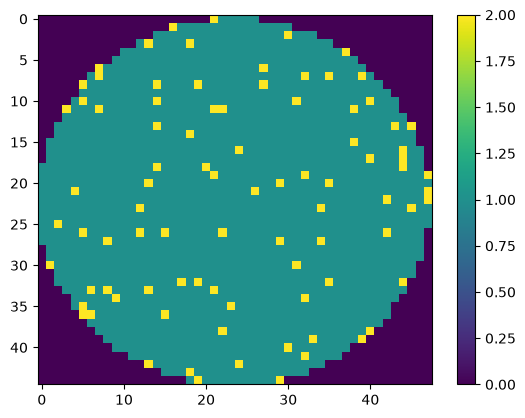

In [21]:
plt.imshow(first_map)
plt.colorbar()
plt.show()

In [22]:
print(df.loc[0, "waferMap"].shape)
print(df.loc[100000, "waferMap"].shape)
print(df.loc[500000, "waferMap"].shape)


(45, 48)
(89, 90)
(32, 29)


In [23]:
first_label = df.loc[0,"failureType"]
print(first_label)
print(type(first_label))
print(first_label.shape)


[['none']]
<class 'numpy.ndarray'>
(1, 1)


In [24]:
print(first_label[0,0])

none


In [25]:
label_shapes = df["failureType"].apply(lambda x: x.shape)
label_shapes.value_counts()

failureType
(0, 0)    638507
(1, 1)    172950
Name: count, dtype: int64

In [26]:
is_labeled = df["failureType"].apply(lambda x : x.size > 0)
df_lab = df[is_labeled].copy()
df_lab.shape

(172950, 6)

In [27]:
df_lab["label"] = df_lab["failureType"].apply(lambda x: x[0,0])
df_lab["label"].value_counts()


label
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

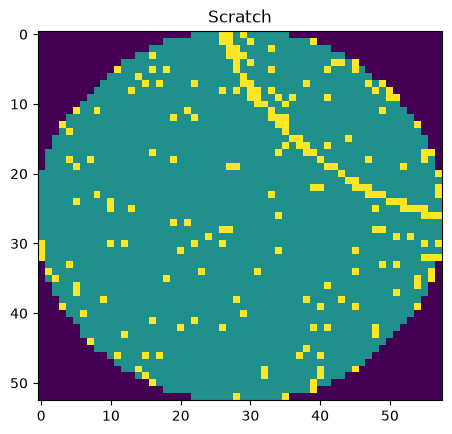

In [28]:
scratch = df_lab[df_lab["label"] == "Scratch"]
plt.imshow(scratch.iloc[0]["waferMap"])
plt.title("Scratch")
plt.show()


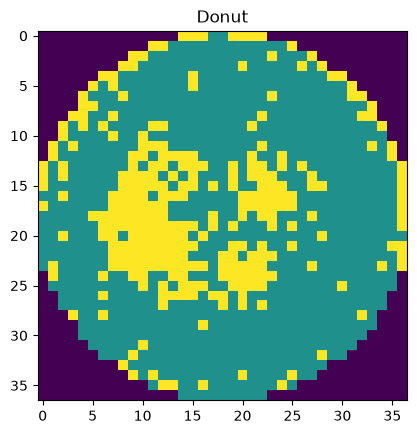

In [29]:
donut = df_lab[df_lab["label"] == "Donut"]
plt.imshow(donut.iloc[0]["waferMap"])
plt.title("Donut")
plt.show()

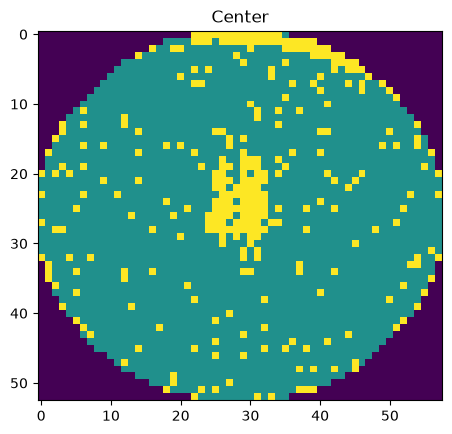

In [30]:
center = df_lab[df_lab["label"] == "Center"]
plt.imshow(center.iloc[0]["waferMap"])
plt.title("Center")
plt.show()

## Summary

- Dataset: WM-811K, 172,950 labelled(21.3%) out of 811,457, un-labelled ones were dropped
- Wafer map: a 2D grid where 0 = no die, 1 = die passed, 2 = die failed
- Problem 1: wafer maps come in different sizes (e.g. 45x48 vs 89x90), so every grid has to be resized to one common size(e.g 64x64) before training.
  
- Problem 2: classes are very imbalanced. "none" is 85% of labeled wafers, the rarest class (Near-Full) has only 149. So accuracy alone does not suffice as a model which only predicted 'none' would be right 85% of the time

In [32]:
df_lab[["waferMap", "label"]].to_pickle("/Users/a./Wafer_project/wafer-defects/data/labeled.pkl")